In [156]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency
import itertools

In [157]:
# skip column analysis since this is already in the data description
# check missing values
# minor data cleaning (remove columns, values, etc that are "not relevant" [customer satisfaction seems suspicious])
# check for outliers --> values are given in data description, however, investigate. given != always actual
# check for duplicates (based on customer ID - check whether this is unique or whether we have Q1 values and Q2 values in there)
# analyse the distribution of the target variable

# check correlation between features and target variable

# create a dataset -> normalizing the data, encoding categorical, ordinal features, etc.

# create a train / val / test split
# intuitively use XGBoost model / logistic regression to predict target variable
# evaluate using metrics such as top-k (precision@k, recall@k), precision, recall, AU-ROC PR-AUC / average precisio
# 


# mabye use top-k as pitch for the task 2
# use SHAP values to explain the model and find out which features are most important for the prediction of churn
# use the insights from the SHAP values to create a customer retention strategy, e.g. by identifying which customers are most likely to churn and targeting them with specific retention efforts

# explain how the model could be pushed to production, api that takes in user data and returns a prediction
# when should the model be run? every day, every week, etc. and how to integrate it into the existing system of the company


In [158]:
# read with every colum forced to lowercase to avoid issues with column names
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CustomerSatisfactionScore,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,NaN,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,NaN,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,6.0,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),NaN,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,1.0,70.70,151.65,Yes


In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   gender                     7043 non-null   str    
 2   SeniorCitizen              7043 non-null   int64  
 3   Partner                    7043 non-null   str    
 4   Dependents                 7043 non-null   str    
 5   tenure                     7043 non-null   int64  
 6   PhoneService               7043 non-null   str    
 7   MultipleLines              7043 non-null   str    
 8   InternetService            7043 non-null   str    
 9   OnlineSecurity             7043 non-null   str    
 10  OnlineBackup               7043 non-null   str    
 11  DeviceProtection           7043 non-null   str    
 12  TechSupport                7043 non-null   str    
 13  StreamingTV                7043 non-null   str    
 14  Str

In [160]:
# check for the length and whether there are duplicated values in the dataset
print("Number of rows in the dataset:", len(df))
print("Number of unique customers in the dataset:", df['customerID'].nunique())
print("We have no duplicated values, so this is a clean dataset when it comes to different customers")

Number of rows in the dataset: 7043
Number of unique customers in the dataset: 7043
We have no duplicated values, so this is a clean dataset when it comes to different customers


# Data analysis

In [161]:
df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')

In [163]:
def visualize_non_numerical_variable(df, columns):
    # create a subplot for each column in columns showing the distribution of the variable in percentage
    n = len(columns)
    nrows = math.ceil(n / 3)
    fig, axes = plt.subplots(nrows, 3, figsize=(12, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        counts = df[column].value_counts(normalize=True) * 100
        colors = plt.cm.tab10(range(len(counts)))
        ax.bar(counts.index.astype(str), counts.values, color=colors)
        ax.set_xlabel(column.capitalize())
        ax.set_ylabel('Percentage (%)')
        ax.set_title(f'Distribution of {column.capitalize()}')
        ax.tick_params(axis='x', rotation=45)
        for i, v in enumerate(counts.values):
            ax.text(i, 0.8, f'{v:.1f}%', ha='center', fontsize=10)
        
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

def non_numerical_churn_distribution(df, columns, target='Churn'):
    """ 
        The goal is to visualize the churn rate next to the plots of the distribution, 
        i.e. a bar chart with the distribution of the variable that let's us answer:
        'These are the number of {column} customers of which X% who churned'
        The goal is an initial visualization of the distribution. 
        Each feature is shown independently, so we can see the distribution of the feature and the churn rate for each category of the feature.
    """
    n = len(columns)
    nrows = math.ceil(n / 3)
    fig, axes = plt.subplots(nrows, 3, figsize=(5 * 3, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        # overall share of each category (bar height)
        category_share = df[column].value_counts(normalize=True) * 100

        # churn rate within each category (stacked split)
        churn_rate = df.groupby(column)[target].apply(lambda x: (x == 'Yes').mean() * 100)
        retain_rate = 100 - churn_rate

        categories = category_share.index.astype(str)
        x = range(len(categories))

        colors = plt.cm.tab10(range(len(categories)))
        ax.bar(x, retain_rate[category_share.index] / 100 * category_share.values,
               color=colors[0], label='Retained')
        ax.bar(x, churn_rate[category_share.index] / 100 * category_share.values,
               bottom=retain_rate[category_share.index] / 100 * category_share.values,
               color=colors[1], label='Churned')

        # annotate total bar height and churn % inside the red segment
        for i, (cat, share) in enumerate(zip(category_share.index, category_share.values)):
            retain_abs = retain_rate[cat] / 100 * share
            ax.text(i, 0.8, f'{share:.1f}% (wd)', ha='center', fontsize=10)
            ax.text(i, retain_abs + 0.8, f'{churn_rate[cat]:.1f}% (cd)',
                    ha='center', fontsize=10)

        ax.set_xticks(list(x))
        ax.set_xticklabels(categories, rotation=15, ha='right')
        ax.set_xlabel(column.capitalize())
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('% of Total Customers')
        ax.set_title(f'{column.capitalize()}')
        ax.legend(fontsize=10)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

def cramers_v(x, y):
    """
        Calculate the correlation via Cramer's V between two categorical variables.
        (similar to pearson correlation, but for categorical variables)
    """
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def categorical_association_matrix(df, columns):
    """
        Drawing the matrix of Cramer's V values for all combinations of categorical variables in the dataframe.
    """
    m = pd.DataFrame(np.eye(len(columns)), index=columns, columns=columns)
    for c1, c2 in itertools.combinations(columns, 2):
        v = cramers_v(df[c1], df[c2])
        m.loc[c1, c2] = m.loc[c2, c1] = v
    return m

visualize the features distribution, what is the percentage of each (non numerical) feature, checking the distribution

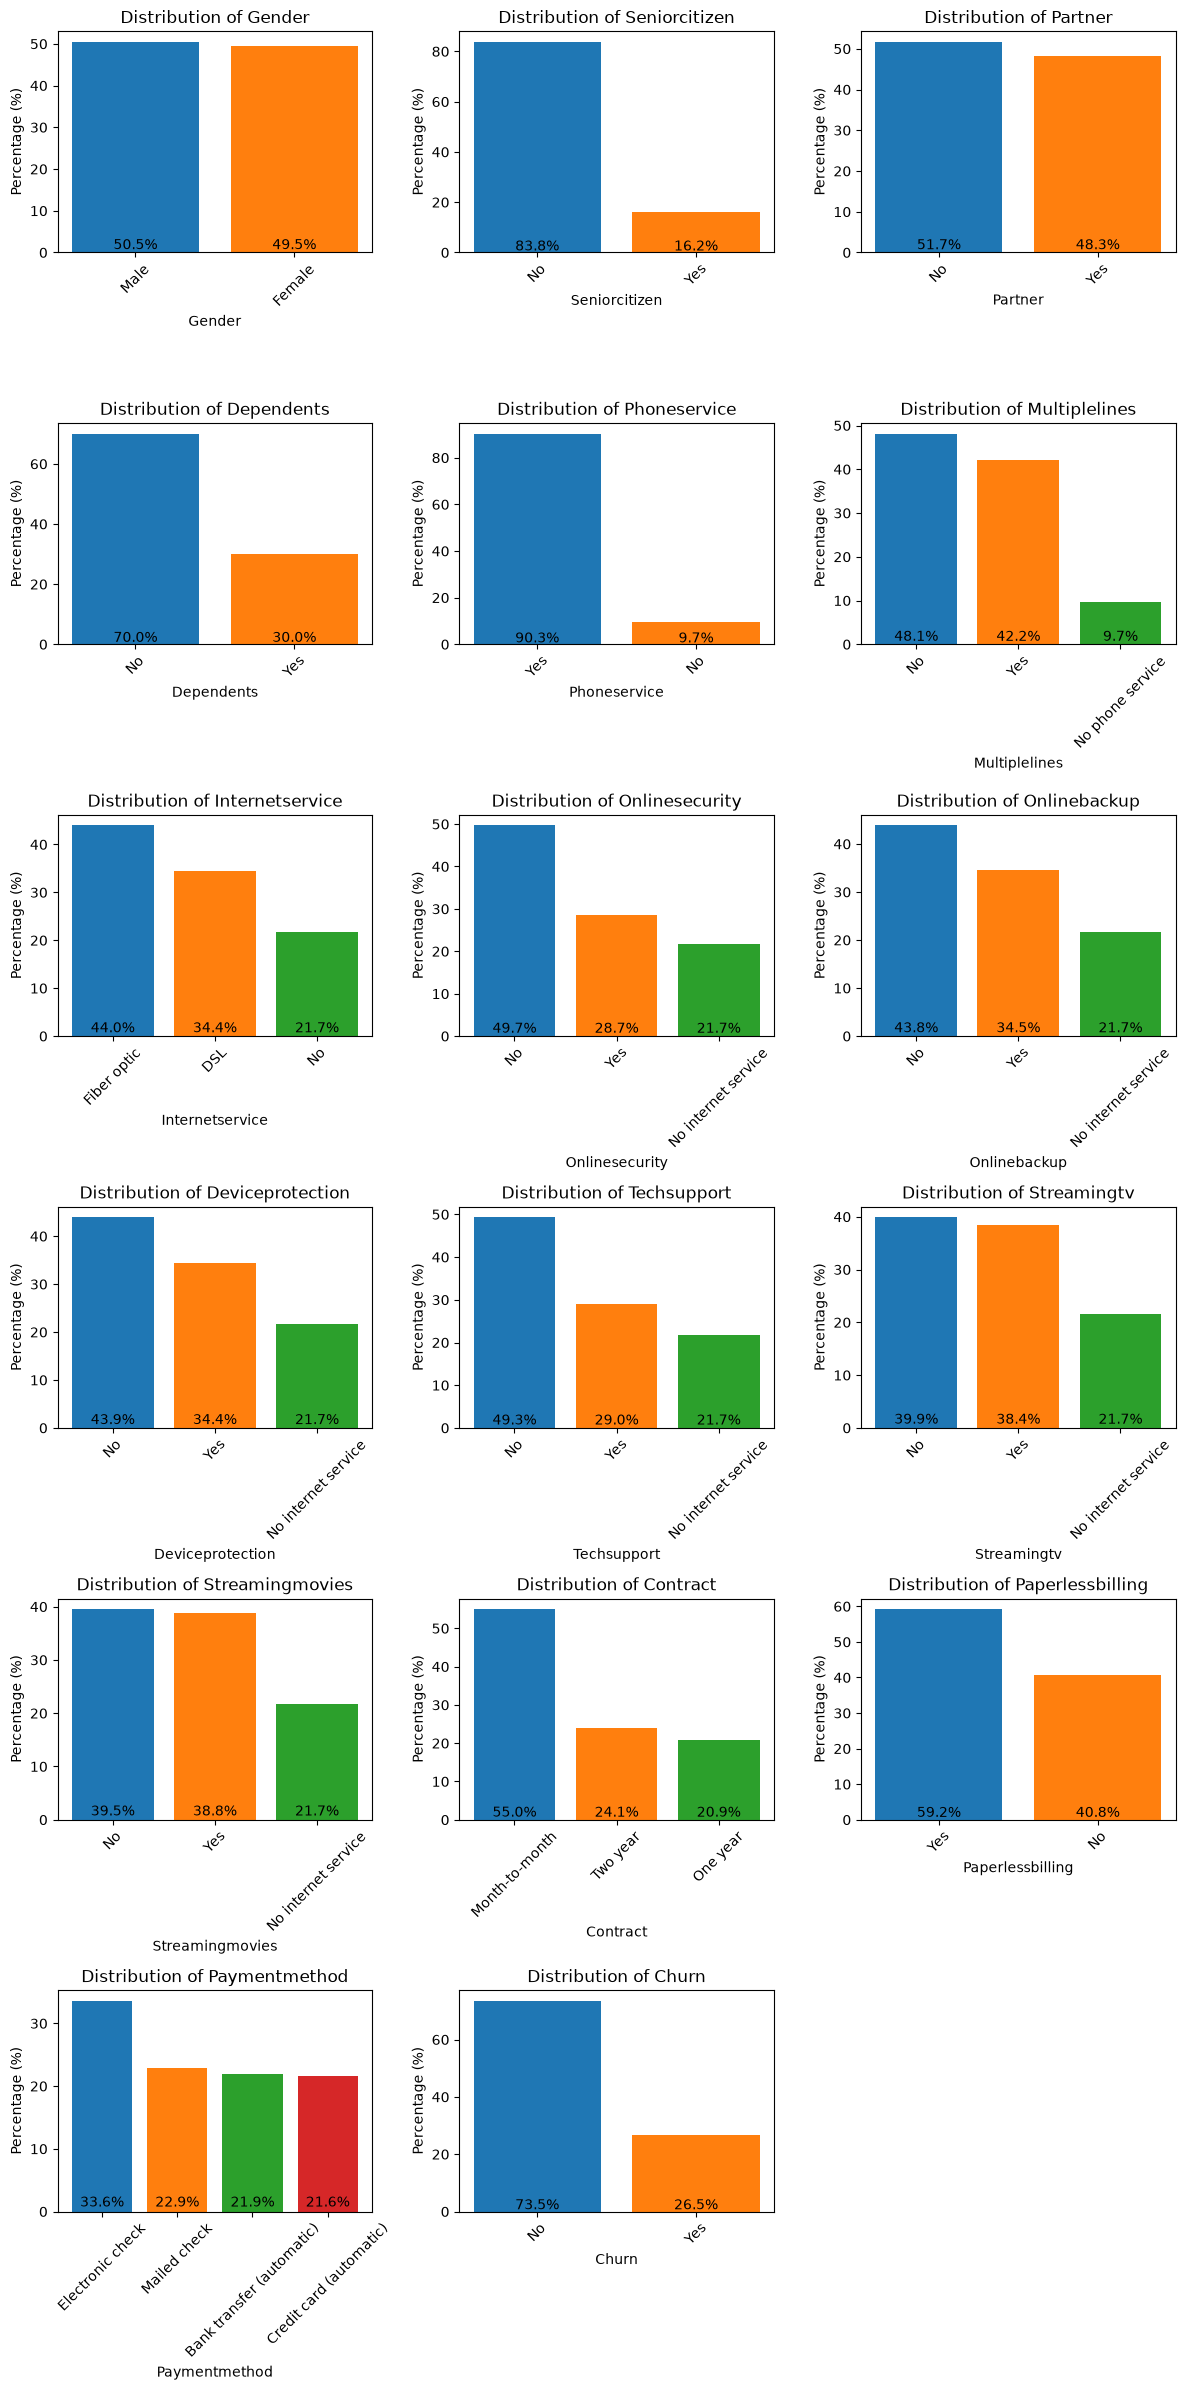

In [140]:
visualize_non_numerical_variable(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'])

putting the feature distribution in relation to the churn rate. i.e. we can see that in gender for instance we have a 26% churn rate on men. the intuition here is that our whole distribution of men is 50%, taking the 50% of men as 100% and only looking at the churn rate of men, this leads us to a churn rate of 26.2% of all men. meaning that 26.2% of all men leave, while 26.9% of all women leave (looking at the woman statistics as a whole). since we are only looking at 2 distributions here, 26% of 50% is 12.5%, and when we add up 12.5%*2 this leaves us with our 26.5% churn rate.

wd = refers to the whole distribution / sample
cd = column distribution (only for one column)


## EDA notes: categorical features vs churn

base churn rate approx. 26%, so anything near that = no signal, anything well above/below = something

gender: looks alike, nearly as many male / female clients churned (26.2% vs 26.9%) 
- cramers v with churn = 0.00 -> zero signal, can be dropped

seniority: senior citizens churn at 41.7% vs 23.6% for non-seniors.
- my guess (longer contracts -> higher cost -> annoyed) is probably backwards, seniors more likely skew month-to-month / fiber. has to be verified
- check directly: crosstab(SeniorCitizen, Contract) and crosstab(SeniorCitizen, InternetService)
- association with churn is only 0.15 -> real but weak, likely a proxy for contract/internet type

partner: no partner churns more (33.0%) than with partner (19.7%) -> having a subscription with a partner seems to lead to a higher lock-in effect

dependents: same direction, no dependents 31.3% vs 15.5% -> underscores the partner intuition, when people are dependent on a subscription it is less likely to be cancelled
- note: partner <-> dependents are correlated (cramers v 0.45), so these two are partly the same story, not independent evidence

phone service: alike (26.7% vs 24.9%), churn association = 0.00 -> useless for churn

multiple lines: alike (~25-29%), association = 0.04
- IMPORTANT: phone service <-> multiple lines = 1.00 (somewhat redundant, multiple lines contains a "no phone service" category fully determined by phone service). we could keep one, drop the other

internet service: 41.9% of all fiber optic customers churned -> something seems off with that service. DSL 19.0%, no internet 7.4%
- this is the most actionable product finding. likely price or service-quality issue with fiber, could flag for the business

online security: no security 41.8% vs yes 14.6% vs no internet 7.4%. similar shape to internet service
online backup: no 39.9% vs yes 21.5% vs no internet 7.4%. similar to internet service
device protection: no 39.1% vs yes 22.5% vs no internet 7.4%. similar to internet service
tech support: no 41.6% vs yes 15.2% vs no internet 7.4%. similar to internet service

-> STRUCTURAL NOTE on the whole internet block:
   all of these (internet service + the 4 add-ons + streaming below) sit at 0.71-0.77 cramers v with EACH OTHER.
   reason: the add-ons are derived from internet service. no internet -> mechanically "no internet service" in all of them (that's the shared 7.4% / 21.7% bucket).
   so these are NOT 6 independent churn signals, they collapse into roughly ONE ("has internet, and what kind")

model note:
   - trees handle the redundancy fine
   - for logistic regression collapse the block; rely on regularization

streaming tv: no 33.5% vs yes 30.1% vs no internet 7.4%. pretty even between yes/no.
streaming movies: no 33.7% vs yes 29.9% vs no internet 7.4%. pretty even.
- streaming tv <-> streaming movies = 0.77 -> people with streaming tv also stream movies, confirmed. weakest churn signal of the internet block (0.23)

contract: month-to-month churns the most (42.7%) vs one year 11.3% vs two year 2.8% -> makes sense, the others are locked in
- STRONGEST single predictor: cramers v with churn = 0.41
- for 1/2 year contracts it would make sense to check when those started (renewal timing)

paperless billing: yes churns more (33.6%) than no (16.3%). association 0.19
- probably a proxy for younger / less committed / digital-only customers rather than a cause. weak but present

payment method: electronic check is the standout -> 45.3% churn, the single highest churn category in the whole dataset
- mailed check 19.1%, bank transfer (auto) 16.7%, credit card (auto) 15.2%
- automatic payment methods churn far less -> payment friction / commitment signal. association 0.30, third strongest

## predictor ranking (cramers v with churn)
contract 0.41 > online security 0.35 > tech support 0.34 > internet service 0.32 > payment method 0.30 > online backup 0.29 > device protection 0.28 > streaming 0.23 > paperless 0.19 > dependents/senior/partner ~0.15 > multiple lines 0.04 > phone service 0.00 > gender 0.00

## numericals missing
this matrix is categorical-only. tenure, monthly charges, total charges are NOT here.
- tenure is usually one of the strongest churn predictors in this kind of data -> check churn rate by tenure bucket.
- total charges ≈ monthly charge × tenure -> expect collinearity, watch for tenure=0 blanks.

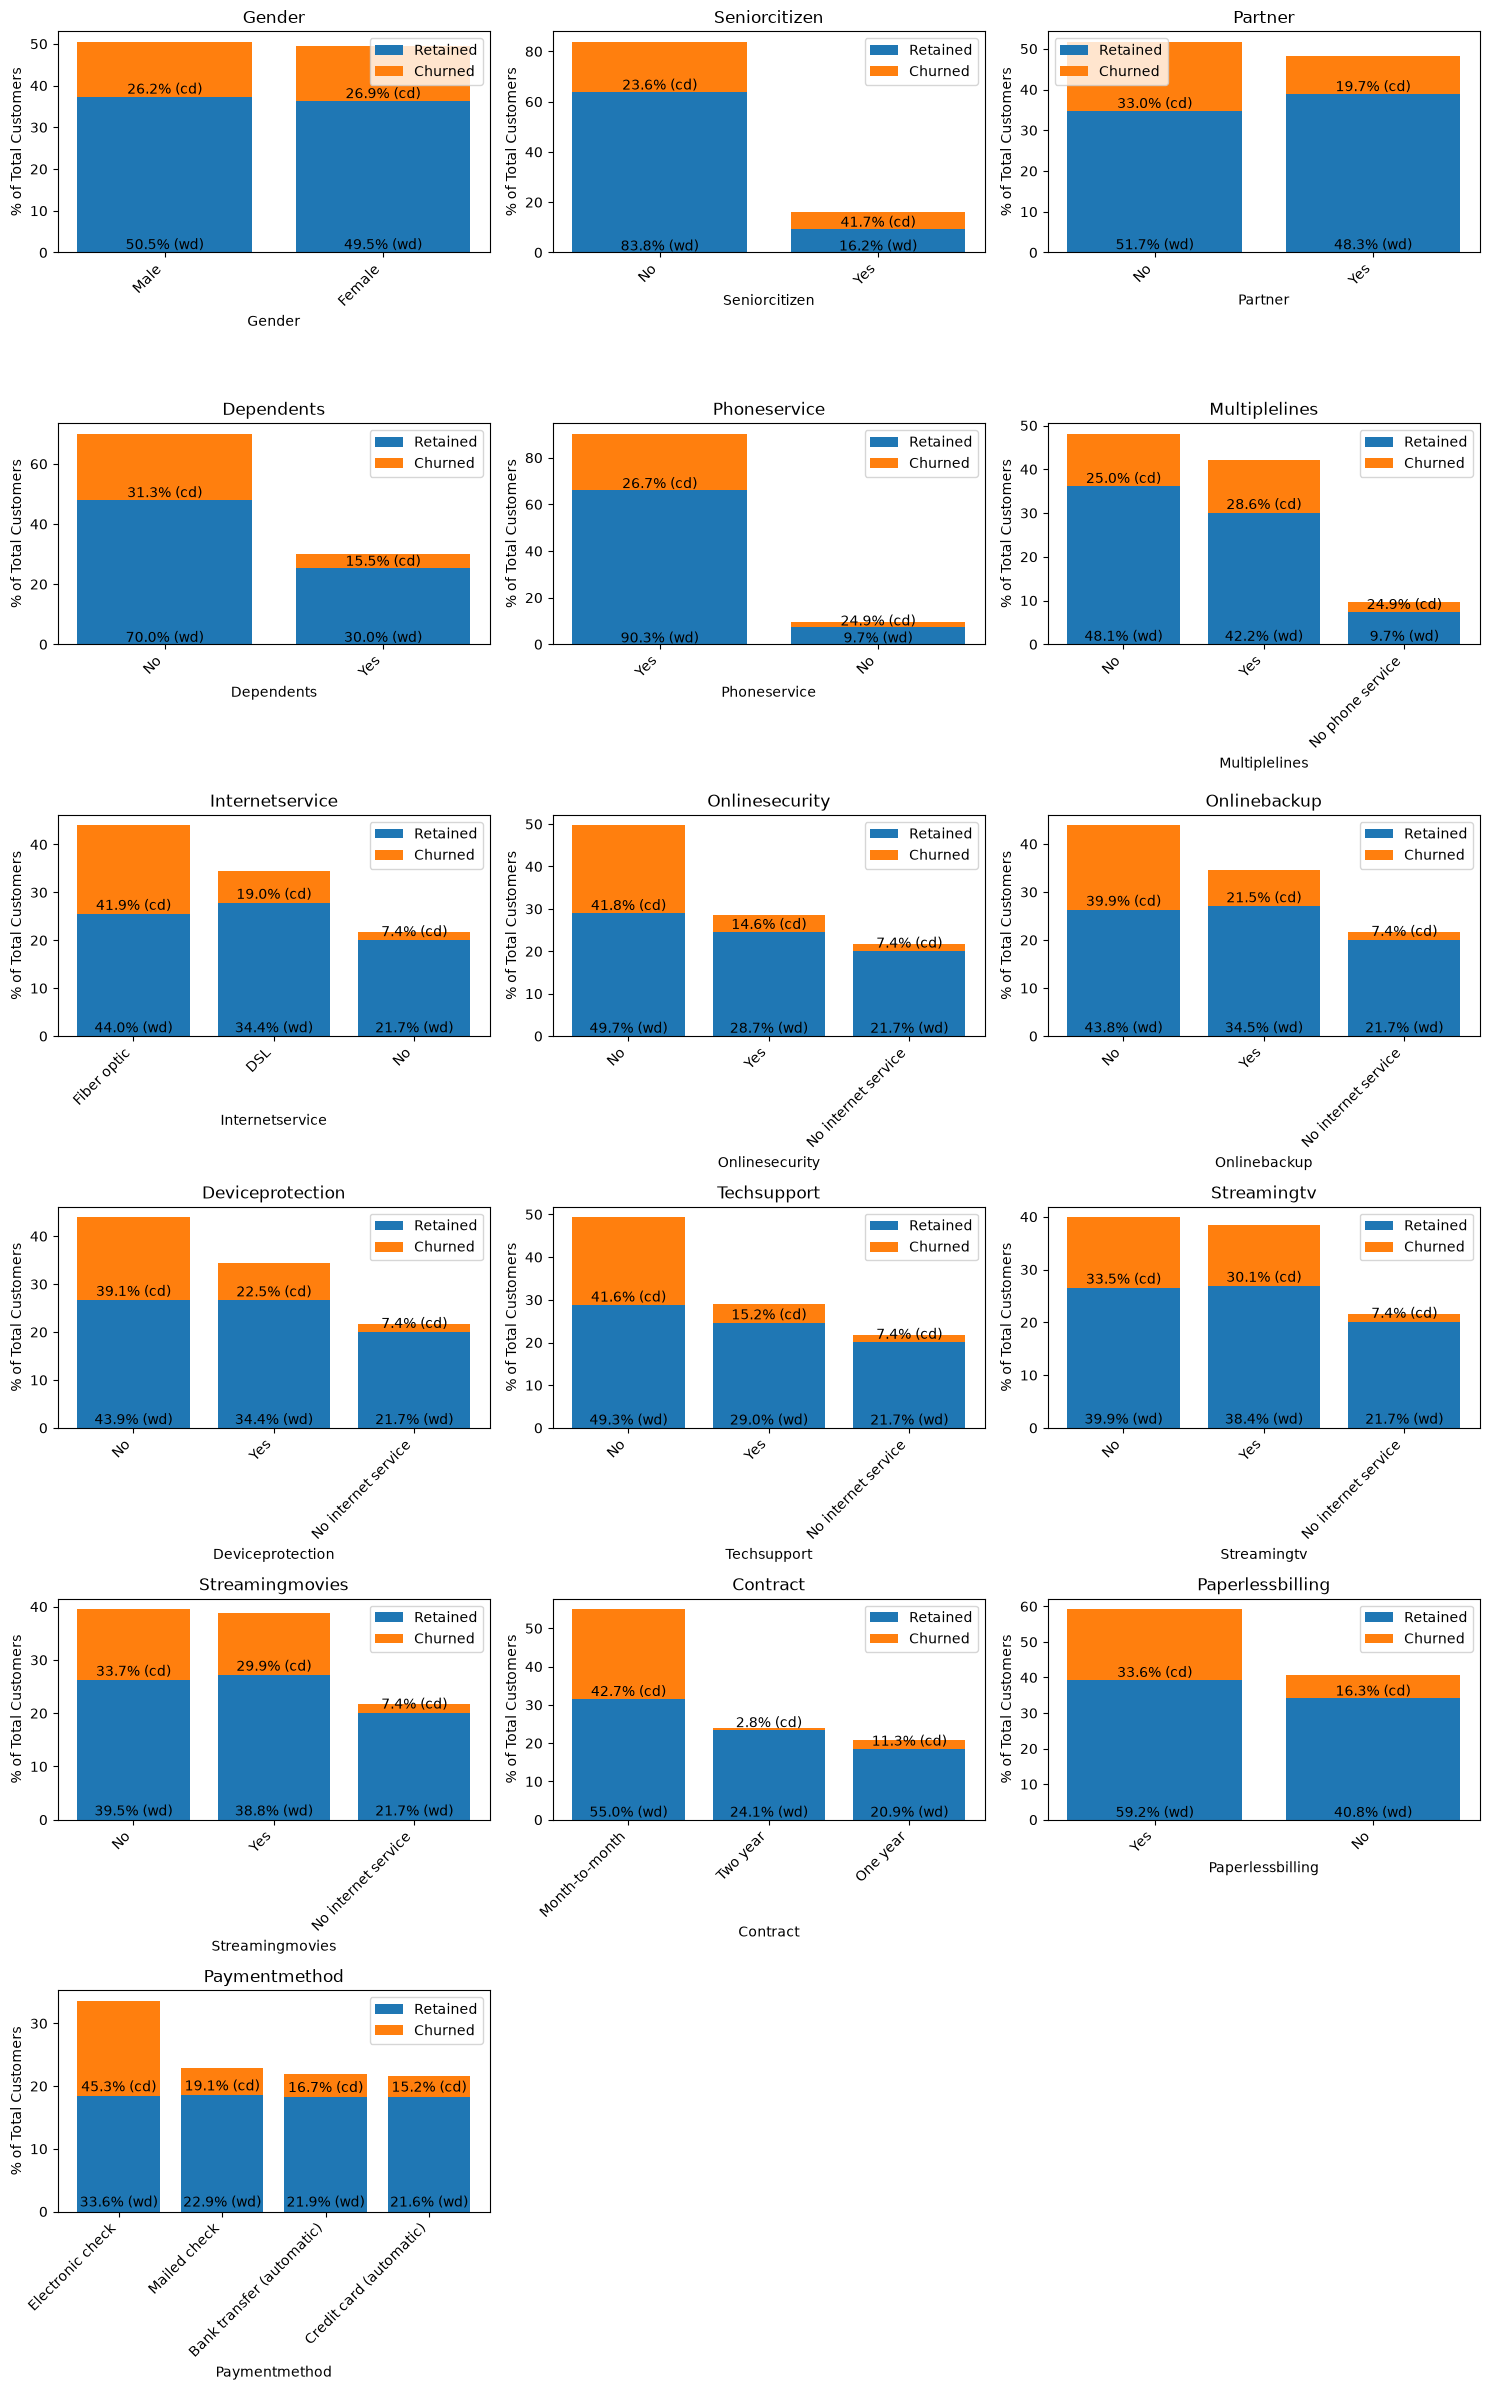

In [138]:

non_numerical_churn_distribution(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])

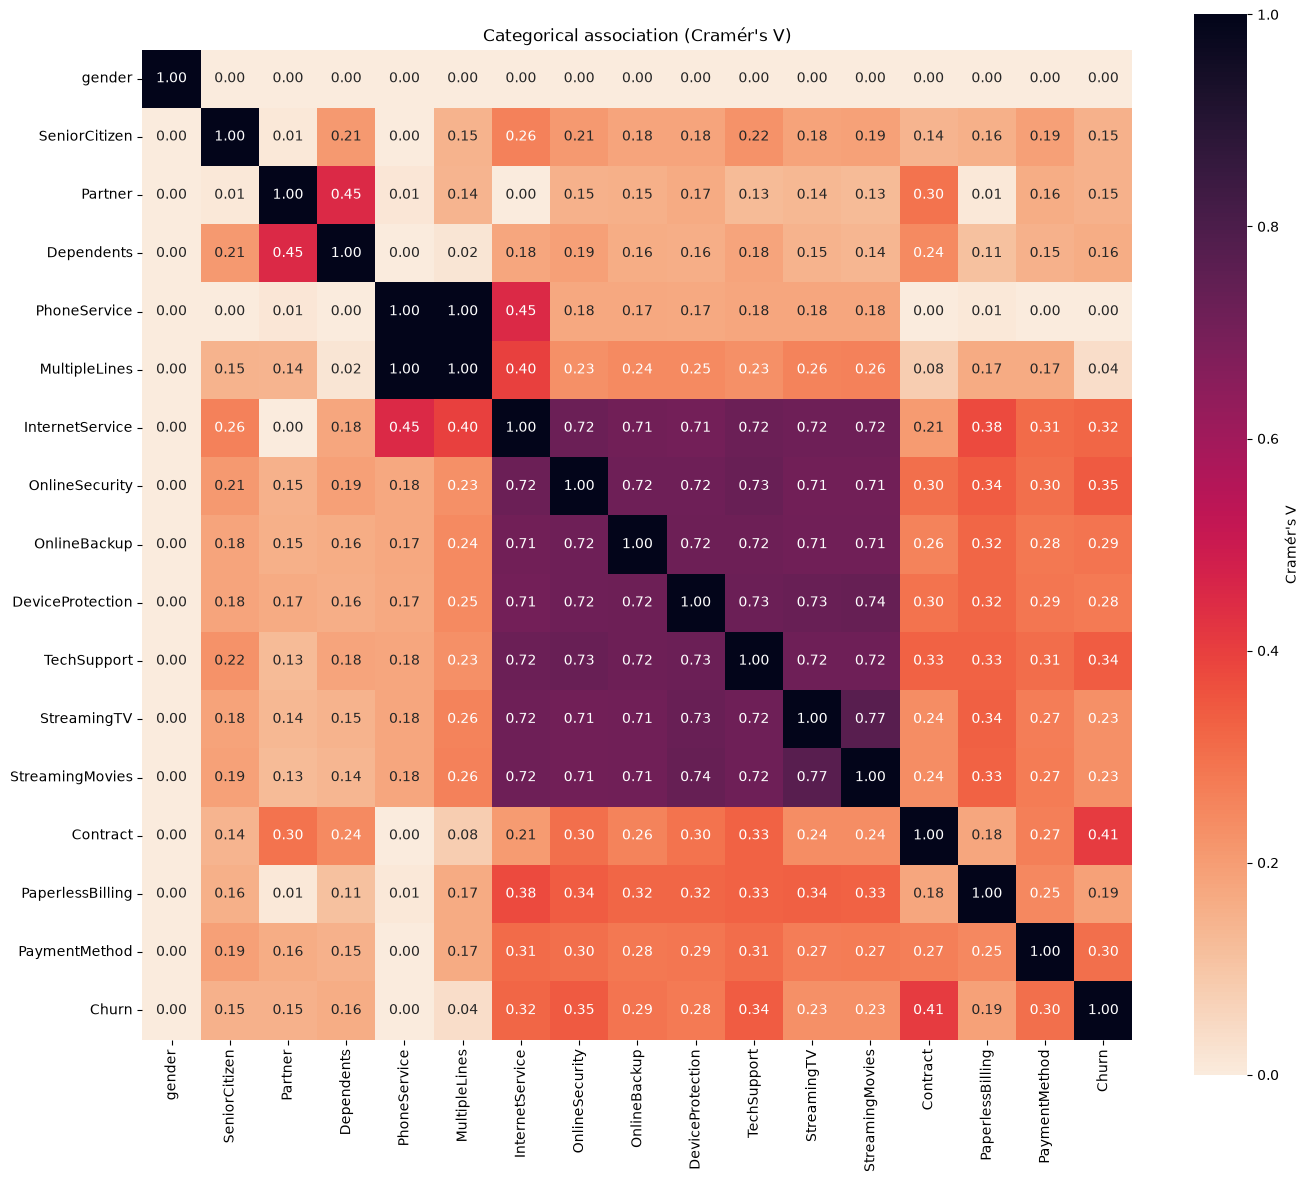

In [164]:
assoc = categorical_association_matrix(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'])

plt.figure(figsize=(14, 12))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='rocket_r', square=True,
            cbar_kws={'label': "Cramér's V"})
plt.title("Categorical association (Cramér's V)")
plt.tight_layout()
plt.show()

## Numericals in the analysis
below we add the numerical attributes to the analysis

In [179]:

for label, sub in df.groupby('Churn'):
    print(f"Churn: {label}")
    print(sub['tenure'].dropna().describe())
    print("\n")

Churn: No
count    5174.000000
mean       37.569965
std        24.113777
min         0.000000
25%        15.000000
50%        38.000000
75%        61.000000
max        72.000000
Name: tenure, dtype: float64


Churn: Yes
count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64




In [187]:
def numerical_churn_distribution(df, columns, target='Churn', bins=30, q=10):
    """"
        Binning the numerical values lets us compare it easier to the target distribution
    """
    fig, axes = plt.subplots(len(columns), 2, figsize=(13, 4 * len(columns)))
    base_churn = (df[target] == 'Yes').mean() * 100
    
    for (ax_l, ax_r), col in zip(axes, columns):

        # left view: histogram of numerical variable vs churn, using pdf to make it comparable with each other (i.e. we compare the shape not the bar height)
        for label, sub in df.groupby(target):
            ax_l.hist(sub[col].dropna(), bins=bins, density=True, alpha=0.5, label=label)
        ax_l.set_title(f'PDF {col} by churn'); ax_l.legend()

        # right view: absolute numbers, we create quantiles and compare them with each other 
        binned = pd.qcut(df[col], q=q, duplicates='drop')
        rate = df.groupby(binned, observed=True)[target].apply(lambda x: (x == 'Yes').mean() * 100)
        rate.plot(kind='bar', ax=ax_r)
        ax_r.axhline(base_churn, ls='--', color='gray')  # base-rate reference
        ax_r.set_title(f'Quantile churn rate by {col} bin'); ax_r.tick_params(axis='x', rotation=45)
    fig.tight_layout(); plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

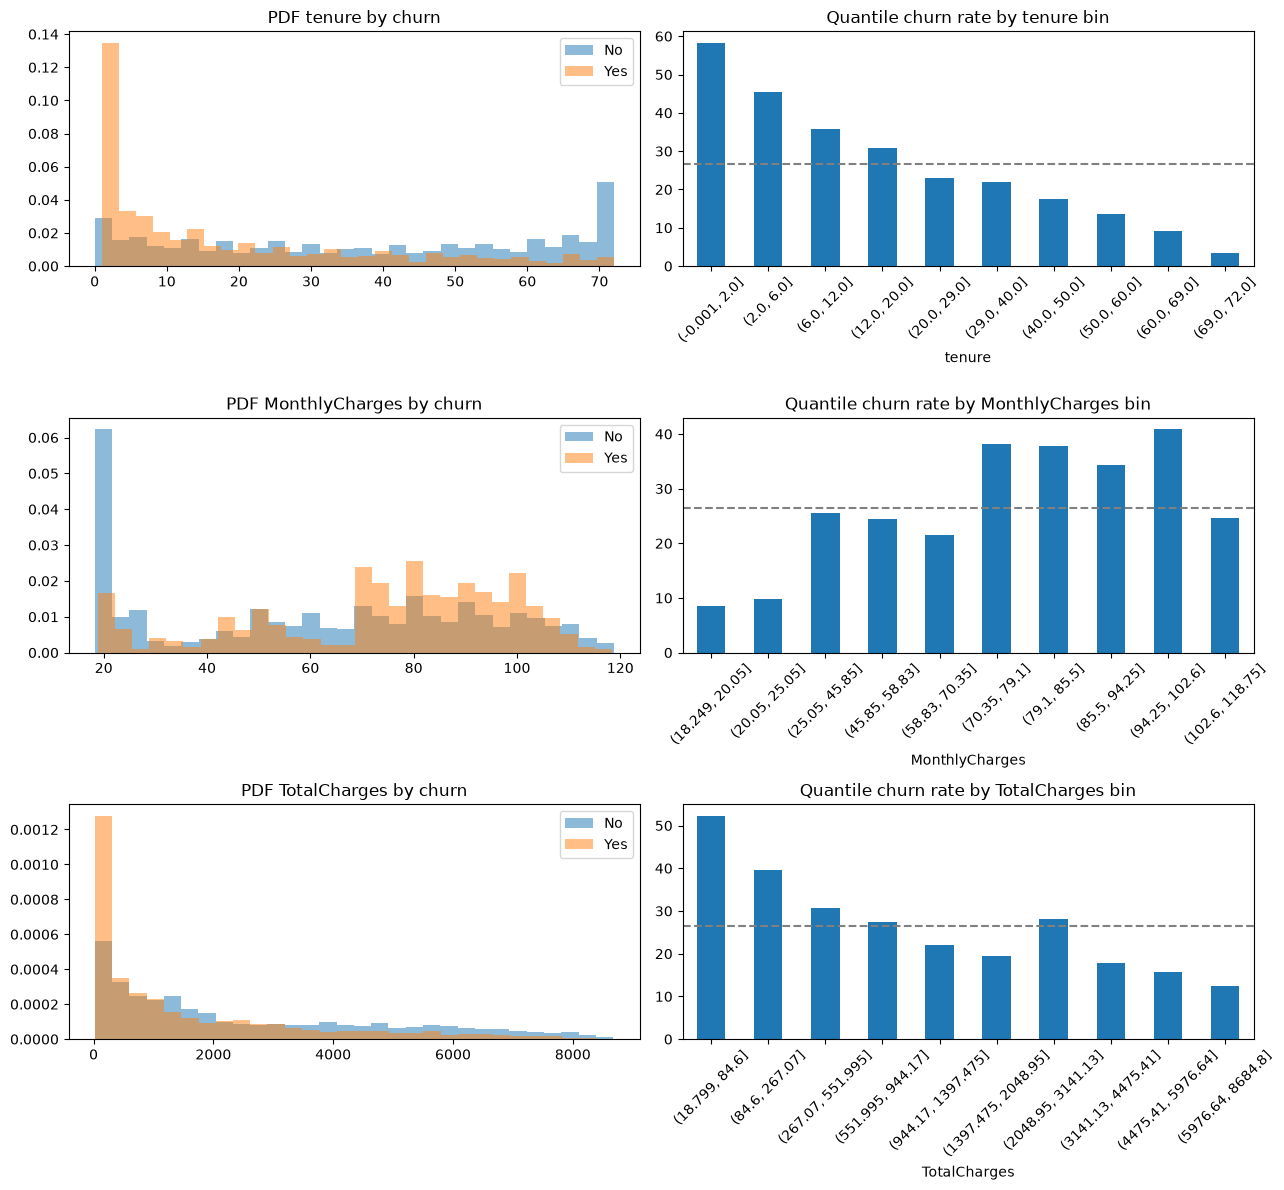

In [190]:
numerical_churn_distribution(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])

Interpretation of the numerical bins:

tenure: most customers churn within the first few months. nearly 60% of customers in the first 2 months switch the provider -> more than double our ~26% average. the churn rate then drops monotonically and falls below average around the 20-29 month bin -> the longer we have a customer, the less likely he is to leave
- there might be a small spike around 12 months (1-year contract customers leaving at renewal?)
- this is the strongest and most independent numerical signal we have

monthly charges: the 70.35-102.6 band has the highest churn rate (34-41%), the cheap subscriptions (~20) are very safe (~9%).
- BUT this is mostly the fiber story in disguise, not an independent price effect:
  - the cheap ~20 customers are the phone-only / no internet group (the same safe 7.4% bucket from internet service).
  - the expensive 70-100 customers are the fiber optic group (the same 41.9% high-churn bucket).
  - so "mid-high charge -> churn" = internet service re-expressed on a continuous axis. do NOT count it as a separate driver.
- correction to my first read: the most expensive bin (102-118) drops back to ~24%, i.e. only at average, NOT well-structured like the cheap tier. the drop at the very top might be heavily-bundled / many-service customers being more locked in -> speculative, has to be verified

total charges: same shape as tenure -> high churn at the start when the customer has barely spent anything, lower the longer we have them
- this is expected and mostly redundant: total charges = monthly charge * tenure, so low total = low tenure = new customer = churn. it is basically tenure (+ a bit of monthly) re-expressed, not an independent third finding
- there is a local bump in the (2048, 3141] bin (around 28% vs 19% neighbors). maybe annual contract customers? -> a guess, has to be verified
- the non-redundant part of total charges is the charge_delta feature (current vs historical avg monthly) -> for later feature engineering, not now

# Combine numerical analysis with categorical analysis

In [ ]:
## combine numericals 

# Feature engineering

# Dataset creation

In [8]:
class ChurnDataset:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)

        # since we already know the dataset we can start with the clean up in the dataset initialization
        # remove columns that are misleading / irrelevant for the analysis (i.e. customer satisfaction)
        self.df = self.df.drop(columns=['customer_satisfaction'])

# Benchmark model creation
A benchmark model could be just random guessing